In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import os
import sys
if '../' not in sys.path:
    sys.path.append('../')

from functools import partial
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from mcp_boltzmann import annihilation as ann

In [6]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

In [40]:
MeV = 1.0
GeV = 1e3*MeV

## Plot quantum statistics corrections

In [ ]:
T_int_QS = np.geomspace(1e-1, 1e2)

sigma_QS = partial(ann.sigma_llff, m_mcp = 1.0, m_f = 0.0)

Ix_table_MB = np.array(
    [ann.Ix(sigma_QS, 1.0, 0.0, T) for T in T_int_QS]
)
Ix_table = np.array(
    [ann.Ix_fermi(sigma_QS, 1.0, 0.0, T) for T in T_int_QS]
)
Ix_table_bose = np.array(
    [ann.Ix_bose(sigma_QS, 1.0, 0.0, T) for T in T_int_QS]
)

(0.1, 100.0)

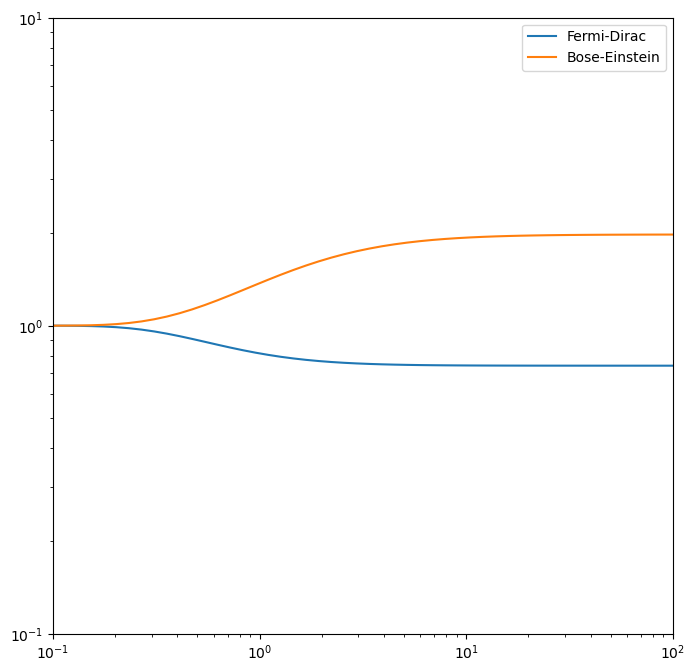

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))
plt.plot(T_int_QS, Ix_table/Ix_table_MB, label='Fermi-Dirac')
plt.plot(T_int_QS, Ix_table_bose/Ix_table_MB, label='Bose-Einstein')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-1, 1e1)
plt.xlim(1e-1, 1e2)

## Load precomputed rates instead of calculating

In [144]:
rates_10MeV = np.load('../output/rates/annihilation/tests/fermionic/mcp_annihilation_rate_m_10.0_Q_1.npz')
rates_1TeV = np.load('../output/rates/annihilation/tests/fermionic/mcp_annihilation_rate_m_1000000.0_Q_1.npz')

## Calculate rates (disabled)

In [9]:
sigma_ee_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_e)
sigma_mumu_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_mu)
sigma_tautau_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_tau)

sigma_lq_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = 0.0) #pretend the charge of quarks is one so we can use this for ups and downs
sigma_ss_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_s, q_f=q_s)
sigma_cc_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_c, q_f=q_c)
sigma_bb_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_b, q_f=q_b)
sigma_tt_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_t, q_f=q_t)

sigma_pipi_ff = partial(ann.sigma_pipi_ff, m_mcp = m_mcp)

In [10]:
sigma_ee_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_e, q_f=-1, cv=cv_e, ca=ca_e)
sigma_mumu_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_mu, q_f=-1, cv=cv_mu, ca=ca_mu)
sigma_tautau_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_tau, q_f=-1, cv=cv_tau, ca=ca_tau)

sigma_uu_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = 0.0, q_f=q_u, cv=cv_u, ca=ca_u)
sigma_dd_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = 0.0, q_f=q_d, cv=cv_d, ca=ca_d)
sigma_ss_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_s, q_f=q_s, cv=cv_s, ca=ca_s)
sigma_cc_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_c, q_f=q_c, cv=cv_c, ca=ca_c)
sigma_bb_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_b, q_f=q_b, cv=cv_b, ca=ca_b)
sigma_tt_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_t, q_f=q_t, cv=cv_t, ca=ca_t)

sigma_nunu_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = 0.0, q_f=0.0, cv=cv_nu, ca=ca_nu)

### Tabulate rates incl Z boson contributions

### Save rates to disk

## Make Plots

### Interpolators for plots below

In [146]:
T_int_10MeV = rates_10MeV['Temp_grid']
rates_10MeV['rate_e']

_Ix_table_e_I_10MeV = interp1d(T_int_10MeV, rates_10MeV['rate_e'], bounds_error=False, fill_value=(0, Ix_table_e[-1]))
_Ix_table_mu_I_10MeV = interp1d(T_int_10MeV, rates_10MeV['rate_mu'], bounds_error=False, fill_value=(0, Ix_table_mu[-1]))
_Ix_table_tau_I_10MeV = interp1d(T_int_10MeV, rates_10MeV['rate_tau'], bounds_error=False, fill_value=(0, Ix_table_tau[-1]))

_Ix_table_lq_I_10MeV = interp1d(T_int_10MeV,rates_10MeV['rate_lq'], bounds_error=False, fill_value=(0, Ix_table_lq[-1]))
_Ix_table_s_I_10MeV = interp1d(T_int_10MeV, rates_10MeV['rate_strange'], bounds_error=False, fill_value=(0, Ix_table_strange[-1]))
_Ix_table_c_I_10MeV = interp1d(T_int_10MeV, rates_10MeV['rate_charm'], bounds_error=False, fill_value=(0, Ix_table_charm[-1]))
_Ix_table_b_I_10MeV = interp1d(T_int_10MeV, rates_10MeV['rate_bot'], bounds_error=False, fill_value=(0, Ix_table_bot[-1]))
_Ix_table_t_I_10MeV = interp1d(T_int_10MeV, rates_10MeV['rate_top'], bounds_error=False, fill_value=(0, Ix_table_top[-1]))

_Ix_table_pi_I_10MeV = interp1d(T_int_10MeV,rates_10MeV['rate_pion'], bounds_error=False, fill_value=(0, Ix_table_pipi[-1]))

_Ix_table_nu_I_10MeV = interp1d(T_int_10MeV,rates_10MeV['rate_nu'], bounds_error=False, fill_value=(0, Ix_table_pipi[-1]))

_Ix_table_W_I_10MeV = interp1d(T_int_10MeV,rates_10MeV['rate_W'], bounds_error=False, fill_value=(0, Ix_table_pipi[-1]))

_Ix_table_tot_I_10MeV  = interp1d(T_int_10MeV,rates_10MeV['rate_tot'], bounds_error=False, fill_value=(0, Ix_table_pipi[-1]))
#######################################################################################################################################
#######################################################################################################################################
T_int_1TeV = rates_1TeV['Temp_grid']
rates_1TeV['rate_e']

_Ix_table_e_I_1TeV = interp1d(T_int_1TeV, rates_1TeV['rate_e'], bounds_error=False, fill_value=(0, Ix_table_e[-1]))
_Ix_table_mu_I_1TeV = interp1d(T_int_1TeV, rates_1TeV['rate_mu'], bounds_error=False, fill_value=(0, Ix_table_mu[-1]))
_Ix_table_tau_I_1TeV = interp1d(T_int_1TeV, rates_1TeV['rate_tau'], bounds_error=False, fill_value=(0, Ix_table_tau[-1]))

_Ix_table_lq_I_1TeV = interp1d(T_int_1TeV,rates_1TeV['rate_lq'], bounds_error=False, fill_value=(0, Ix_table_lq[-1]))
_Ix_table_s_I_1TeV = interp1d(T_int_1TeV, rates_1TeV['rate_strange'], bounds_error=False, fill_value=(0, Ix_table_strange[-1]))
_Ix_table_c_I_1TeV = interp1d(T_int_1TeV, rates_1TeV['rate_charm'], bounds_error=False, fill_value=(0, Ix_table_charm[-1]))
_Ix_table_b_I_1TeV = interp1d(T_int_1TeV, rates_1TeV['rate_bot'], bounds_error=False, fill_value=(0, Ix_table_bot[-1]))
_Ix_table_t_I_1TeV = interp1d(T_int_1TeV, rates_1TeV['rate_top'], bounds_error=False, fill_value=(0, Ix_table_top[-1]))

_Ix_table_pi_I_1TeV = interp1d(T_int_1TeV,rates_1TeV['rate_pion'], bounds_error=False, fill_value=(0, Ix_table_pipi[-1]))

_Ix_table_nu_I_1TeV = interp1d(T_int_1TeV,rates_1TeV['rate_nu'], bounds_error=False, fill_value=(0, Ix_table_pipi[-1]))

_Ix_table_W_I_1TeV = interp1d(T_int_1TeV,rates_1TeV['rate_W'], bounds_error=False, fill_value=(0, Ix_table_pipi[-1]))

_Ix_table_tot_I_1TeV  = interp1d(T_int_1TeV,rates_1TeV['rate_tot'], bounds_error=False, fill_value=(0, Ix_table_pipi[-1]))

### Forwards Collision terms

In [147]:
def C_f_ee_10MeV(T, Q):
    return Q**2*_Ix_table_e_I_10MeV(T)

def C_f_mumu_10MeV(T, Q):
    return Q**2*_Ix_table_mu_I_10MeV(T)

def C_f_tautau_10MeV(T, Q):
    return Q**2*_Ix_table_tau_I_10MeV(T)

def C_f_lq_10MeV(T, Q):
    q_u = 2/3
    q_d = -1/3
    N_c = 3

    return N_c*Q**2*(q_u**2 + q_d**2)*_Ix_table_lq_I_10MeV(T)

def C_f_ss_10MeV(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_s_I_10MeV(T) 

def C_f_cc_10MeV(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_c_I_10MeV(T) 

def C_f_bb_10MeV(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_b_I_10MeV(T) 

def C_f_tt_10MeV(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_t_I_10MeV(T) 

def C_f_pipi_10MeV(T, Q):
    return Q**2*_Ix_table_pi_I_10MeV(T)

def C_f_nunu_10MeV(T, Q):
    return 6*Q**2*_Ix_table_nu_I_10MeV(T)

def C_f_WW_10MeV(T, Q):
    return 6*Q**2*_Ix_table_W_I_10MeV(T)

#######################################################################################################################################
#######################################################################################################################################

def C_f_ee_1TeV(T, Q):
    return Q**2*_Ix_table_e_I_1TeV(T)

def C_f_mumu_1TeV(T, Q):
    return Q**2*_Ix_table_mu_I_1TeV(T)

def C_f_tautau_1TeV(T, Q):
    return Q**2*_Ix_table_tau_I_1TeV(T)

def C_f_lq_1TeV(T, Q):
    q_u = 2/3
    q_d = -1/3
    N_c = 3

    return N_c*Q**2*(q_u**2 + q_d**2)*_Ix_table_lq_I_1TeV(T)

def C_f_ss_1TeV(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_s_I_1TeV(T) 

def C_f_cc_1TeV(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_c_I_1TeV(T) 

def C_f_bb_1TeV(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_b_I_1TeV(T) 

def C_f_tt_1TeV(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_t_I_1TeV(T) 

def C_f_pipi_1TeV(T, Q):
    return Q**2*_Ix_table_pi_I_1TeV(T)

def C_f_nunu_1TeV(T, Q):
    return 6*Q**2*_Ix_table_nu_I_1TeV(T)

def C_f_WW_1TeV(T, Q):
    return 6*Q**2*_Ix_table_W_I_1TeV(T)

### M_mcp = 10 MeV. The plot from adshead et al does not have the muon contribution for T < Lambda QCD

In [181]:
T_plot = np.geomspace(1e-3, 1e6, 1000)

In [182]:
shelton_f_ann = load_csv('../input/fig/2206.13530_fig7_left_annihilation.csv')
# shelton_f_ann_fig8 = load_csv('../input/fig/2206.13530_fig8_left_annihilation.csv')

In [188]:
LQCD = 200
res_e = C_f_ee_10MeV(T_plot, 1e-9)/T_plot**6
res_mu = C_f_mumu_10MeV(T_plot, 1e-9)/T_plot**6
res_tau =  C_f_tautau_10MeV(T_plot, 1e-9)/T_plot**6

res_lq = C_f_lq_10MeV(T_plot, 1e-9)/T_plot**6
res_s = C_f_ss_10MeV(T_plot, 1e-9)/T_plot**6
res_c = C_f_cc_10MeV(T_plot, 1e-9)/T_plot**6
res_b = C_f_bb_10MeV(T_plot, 1e-9)/T_plot**6
res_t = C_f_tt_10MeV(T_plot, 1e-9)/T_plot**6

res_nu = C_f_nunu_10MeV(T_plot, 1e-9)/T_plot**6
res_W = C_f_WW_10MeV(T_plot, 1e-9)/T_plot**6

res_pi = np.heaviside(LQCD - T_plot , 0)*C_f_pipi_10MeV(T_plot, 1e-9)/T_plot**6
res_em = res_e  + res_tau
res_qcd = (res_lq + res_s + res_c + res_b + res_t)
# res_qcd = (res_lq + res_s + res_t)

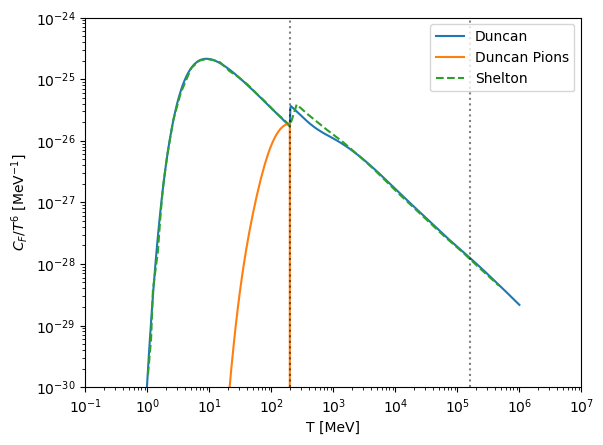

In [190]:
LQCD = 200*MeV
T_EW = 160*GeV


plt.plot(T_plot, (res_em + res_qcd + res_nu), label='Duncan')
plt.plot(T_plot, (res_pi), label='Duncan Pions')


plt.plot(np.array(shelton_f_ann[0])*1e3, shelton_f_ann[1], label='Shelton', linestyle='dashed')

plt.yscale('log')
plt.xscale('log')

plt.ylim(1e-30, 1e-24)
plt.xlim(1e-1, 1e7)

plt.xlabel('T [MeV]')
plt.ylabel(r'$C_{F}/T^6$ [MeV$^{-1}$]')

plt.axvline(LQCD, linestyle='dotted', color='black', alpha=0.5)
plt.axvline(T_EW, linestyle='dotted', color='black', alpha=0.5)



plt.legend()

plt.show()

### M_mcp = 10 TeV

In [157]:
T_plot = np.geomspace(1e5, 1e9, 1000)
shelton_f_ann = load_csv('../input/fig/2206.13530_fig7_right_annihilation.csv')

In [176]:
LQCD = 200
res_e = C_f_ee_1TeV(T_plot, 1e-9)/T_plot**6
res_mu = C_f_mumu_1TeV(T_plot, 1e-9)/T_plot**6
res_tau =  C_f_tautau_1TeV(T_plot, 1e-9)/T_plot**6

res_lq = C_f_lq_1TeV(T_plot, 1e-9)/T_plot**6
res_s = C_f_ss_1TeV(T_plot, 1e-9)/T_plot**6
res_c = C_f_cc_1TeV(T_plot, 1e-9)/T_plot**6
res_b = C_f_bb_1TeV(T_plot, 1e-9)/T_plot**6
res_t = C_f_tt_1TeV(T_plot, 1e-9)/T_plot**6

res_nu = C_f_nunu_1TeV(T_plot, 1e-9)/T_plot**6
res_W = C_f_WW_1TeV(T_plot, 1e-9)/T_plot**6

res_pi = np.heaviside(LQCD - T_plot , 0)*C_f_pipi_1TeV(T_plot, 1e-9)/T_plot**6
res_em = res_e +  res_tau
res_qcd = (res_lq + res_s + res_c + res_b + res_t)
# res_qcd = (res_lq + res_s + res_t)

res_tot = res_em + res_qcd + res_nu

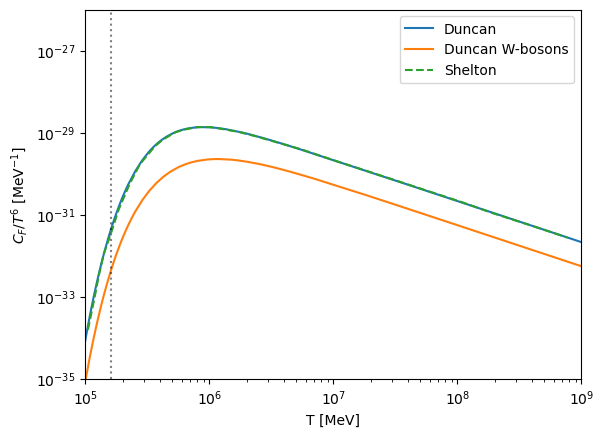

In [179]:
LQCD = 200*MeV
T_EW = 160*GeV


plt.plot(T_plot, (res_tot), label='Duncan')
plt.plot(T_plot, (res_W), label='Duncan W-bosons')


plt.plot(np.array(shelton_f_ann[0])*1e3, shelton_f_ann[1], label='Shelton', linestyle='dashed')

plt.yscale('log')
plt.xscale('log')

plt.ylim(1e-35, 1e-26)
plt.xlim(1e5, 1e9)

plt.xlabel('T [MeV]')
plt.ylabel(r'$C_{F}/T^6$ [MeV$^{-1}$]')

plt.axvline(LQCD, linestyle='dotted', color='black', alpha=0.5)
plt.axvline(T_EW, linestyle='dotted', color='black', alpha=0.5)



plt.legend()

plt.show()